In [13]:
# PinchBench MiniMax 结果预处理：将 4 段分开 run 的 JSON 合成为一个 merged JSON
import json
from pathlib import Path
from copy import deepcopy

_MINIMAX_SOURCE_PATH = Path("/root/skill/results/rq1/pinchbench_minimax-cn-MiniMax-M2-5.json")
_MERGED_RESULTS_PATH = Path("/root/skill/results/rq1/pinchbench_minimax-cn-MiniMax-M2-5__merged.json")
RESULTS_PATH_GPT5_3 = "/root/skill/results/rq1/pinchbench_autodl-gpt-5-3-codex.json"

_raw_minimax = json.loads(_MINIMAX_SOURCE_PATH.read_text(encoding="utf-8"))
if isinstance(_raw_minimax, dict):
    _merged_result = deepcopy(_raw_minimax)
elif isinstance(_raw_minimax, list):
    if not _raw_minimax:
        raise ValueError(f"No runs found in {_MINIMAX_SOURCE_PATH}")

    _merged_tasks = []
    _efficiency_per_task = []
    _sum_keys = [
        "total_tokens",
        "total_input_tokens",
        "total_output_tokens",
        "total_cache_tokens",
        "total_cache_read_tokens",
        "total_cache_write_tokens",
        "total_cost_usd",
        "total_requests",
        "total_execution_time_seconds",
    ]
    _efficiency_sum = {key: 0.0 for key in _sum_keys}
    _success_at_k_counts = {}
    _task_count = 0
    _success_count = 0
    _score_sum = 0.0

    for run in _raw_minimax:
        _merged_tasks.extend(run.get("tasks") or [])
        _task_count += len(run.get("tasks") or [])

        eff = run.get("efficiency") or {}
        _efficiency_per_task.extend(eff.get("per_task") or [])
        for key in _sum_keys:
            _efficiency_sum[key] += float(eff.get(key) or 0)
        _success_count += int(round((float(eff.get("success_rate") or 0)) * len(run.get("tasks") or [])))
        _score_sum += float(eff.get("score_per_1k_tokens") or 0) * float(eff.get("total_tokens") or 0) / 1000.0
        for k, v in (eff.get("success_at_k") or {}).items():
            _success_at_k_counts[k] = _success_at_k_counts.get(k, 0.0) + float(v) * len(run.get("tasks") or [])

    _base = deepcopy(_raw_minimax[0])
    _base["tasks"] = _merged_tasks
    _base["run_id"] = "+".join(str(run.get("run_id", "")) for run in _raw_minimax)
    _base["timestamp"] = max(str(run.get("timestamp", "")) for run in _raw_minimax)
    _base["efficiency"] = {
        **_efficiency_sum,
        "tasks_with_usage_data": _task_count,
        "per_task": _efficiency_per_task,
        "tokens_per_task": (_efficiency_sum["total_tokens"] / _task_count) if _task_count else None,
        "cost_per_task_usd": (_efficiency_sum["total_cost_usd"] / _task_count) if _task_count else None,
        "success_rate": (_success_count / _task_count) if _task_count else None,
        "success_per_1k_tokens": (_success_count / (_efficiency_sum["total_tokens"] / 1000.0)) if _efficiency_sum["total_tokens"] else None,
        "score_per_1k_tokens": (_score_sum / (_efficiency_sum["total_tokens"] / 1000.0)) if _efficiency_sum["total_tokens"] else None,
        "score_per_dollar": None if not _efficiency_sum["total_cost_usd"] else None,
        "success_per_dollar": None if not _efficiency_sum["total_cost_usd"] else None,
        "success_at_k": {k: (_success_at_k_counts[k] / _task_count) for k in sorted(_success_at_k_counts, key=lambda x: int(x))},
    }
    _merged_result = _base
else:
    raise TypeError(f"Unsupported payload type in {_MINIMAX_SOURCE_PATH}: {type(_raw_minimax).__name__}")

_MERGED_RESULTS_PATH.write_text(json.dumps(_merged_result, ensure_ascii=False, indent=2), encoding="utf-8")
RESULTS_PATH = str(_MERGED_RESULTS_PATH)
RESULTS_PATH_MINIMAX2_5 = str(_MERGED_RESULTS_PATH)

print(f"Merged MiniMax runs: {len(_raw_minimax) if isinstance(_raw_minimax, list) else 1}")
print(f"Merged MiniMax task count: {len(_merged_result.get('tasks') or [])}")
print(f"Merged MiniMax output: {_MERGED_RESULTS_PATH}")
print(f"GPT result path: {RESULTS_PATH_GPT5_3}")


Merged MiniMax runs: 4
Merged MiniMax task count: 23
Merged MiniMax output: /root/skill/results/rq1/pinchbench_minimax-cn-MiniMax-M2-5__merged.json
GPT result path: /root/skill/results/rq1/pinchbench_autodl-gpt-5-3-codex.json


In [14]:
# 每次 attempt 的 score + token 使用，以及单次 vs 多次 attempt 的对比
import json
from pathlib import Path

import pandas as pd

# 结果文件路径：默认使用上方预处理 cell 产出的 merged JSON
RESULTS_PATH = globals().get("RESULTS_PATH", "/root/skill/results/rq1/pinchbench_minimax-cn-MiniMax-M2-5__merged.json")
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    _data = json.load(f)

_tasks = _data.get("tasks", [])
_efficiency = _data.get("efficiency", {}) or {}
_per_task_eff = {x["task_id"]: x for x in (_efficiency.get("per_task") or [])}

# 1) 每次 attempt 的明细：score + tokens
attempt_rows = []

for t in _tasks:
    task_id = t.get("task_id", "")
    name = (t.get("frontmatter") or {}).get("name") or task_id
    attempts = t.get("attempts") or []

    for a in attempts:
        g = a.get("grading") or {}
        ex = a.get("execution") or {}
        u = (ex.get("usage") or {}) or (a.get("usage") or {})

        attempt_rows.append({
            "task_id": task_id,
            "name": name,
            "attempt": int(a.get("attempt", 0)),
            "score": float(g.get("score", 0)),
            "max_score": float(g.get("max_score", 1) or 1),
            "execution_time": float(ex.get("execution_time", 0)),
            "status": ex.get("status", ""),
            "input_tokens": float(u.get("input_tokens") or 0),
            "output_tokens": float(u.get("output_tokens") or 0),
            "total_tokens": float(u.get("total_tokens") or 0),
        })

if attempt_rows:
    df_attempts = pd.DataFrame(attempt_rows)
    df_attempts["score_pct"] = (df_attempts["score"] / df_attempts["max_score"].replace(0, 1) * 100).round(1)
    display(df_attempts[[
        "task_id", "attempt", "score", "max_score", "score_pct",
        "execution_time", "status",
        "input_tokens", "output_tokens", "total_tokens",
    ]])
else:
    print("没有 attempt 明细数据。")

# 2) 对比：仅第一次 attempt vs 允许多次 attempt 后的最终结果

# 每个任务取「仅第一次 attempt」的 score + token（区分 input/output）
first_attempt_scores = []
first_input_tokens = []
first_output_tokens = []
first_total_tokens_incl_cache = []

# 每个任务取「允许多次 attempt 后的最终」score 和「全部 attempt 累计」token
final_scores = []
all_input_tokens = []
all_output_tokens = []
all_total_tokens_incl_cache = []

for t in _tasks:
    attempts = t.get("attempts") or []
    comp = t.get("completion") or {}

    # 最终得分（多次 attempt 下的结果）
    final_scores.append(float(comp.get("score", 0)))

    task_input_sum = 0.0
    task_output_sum = 0.0
    task_total_sum = 0.0
    first_score = None
    first_in = None
    first_out = None
    first_total = None

    for a in attempts:
        ex = a.get("execution") or {}
        u = (ex.get("usage") or {}) or (a.get("usage") or {})

        in_tok = float(u.get("input_tokens", u.get("input", 0)) or 0)
        out_tok = float(u.get("output_tokens", u.get("output", 0)) or 0)
        total_tok = float(u.get("total_tokens", u.get("totalTokens", 0)) or 0)

        task_input_sum += in_tok
        task_output_sum += out_tok
        task_total_sum += total_tok

        if first_total is None:
            first_in = in_tok
            first_out = out_tok
            first_total = total_tok
            g = a.get("grading") or {}
            first_score = float(g.get("score", 0))

    all_input_tokens.append(task_input_sum)
    all_output_tokens.append(task_output_sum)
    all_total_tokens_incl_cache.append(task_total_sum)

    first_attempt_scores.append(first_score if first_score is not None else 0.0)
    first_input_tokens.append(first_in if first_in is not None else 0.0)
    first_output_tokens.append(first_out if first_out is not None else 0.0)
    first_total_tokens_incl_cache.append(first_total if first_total is not None else 0.0)

n_tasks = len(_tasks)

# 汇总表：两行对比（显式区分 input/output 以及 total 是否含 cache）
summary = [
    {
        "场景": "仅第一次 attempt（不允许多次重试）",
        "任务数": n_tasks,
        "所有任务平均 score": sum(first_attempt_scores) / n_tasks if n_tasks else 0,
        "输入 token 总和（不含 cache）": sum(first_input_tokens),
        "输出 token 总和（不含 cache）": sum(first_output_tokens),
        "total_tokens 总和（一般含 cache）": sum(first_total_tokens_incl_cache),
    },
    {
        "场景": "允许多次 attempt（取最终得分，统计全部 attempt 的 token）",
        "任务数": n_tasks,
        "所有任务平均 score": sum(final_scores) / n_tasks if n_tasks else 0,
        "输入 token 总和（不含 cache）": sum(all_input_tokens),
        "输出 token 总和（不含 cache）": sum(all_output_tokens),
        "total_tokens 总和（一般含 cache）": sum(all_total_tokens_incl_cache),
    },
]

summary_df = pd.DataFrame(summary)
print("引入多次 attempt 前后对比（同一批任务，区分 input/output）：")
display(summary_df)


,task_id,attempt,score,max_score,score_pct,execution_time,status,input_tokens,output_tokens,total_tokens
0,task_00_sanity,1,1.0000,1.0,100.0,17.853824,success,34.0,26.0,11651.0
1,task_01_calendar,1,1.0000,1.0,100.0,25.826634,success,1098.0,600.0,36497.0
2,task_02_stock,1,1.0000,1.0,100.0,86.028892,success,124217.0,1542.0,241524.0
3,task_03_blog,1,0.9075,1.0,90.8,36.904215,success,909.0,883.0,24967.0
4,task_03_blog,2,0.9075,1.0,90.8,2.308990,success,4751.0,1034.0,41630.0
...,...,...,...,...,...,...,...,...,...,...
89,task_17_email_search,3,0.9160,1.0,91.6,-39.418853,success,73042.0,2649.0,161614.0
90,task_17_email_search,4,0.9100,1.0,91.0,22.201181,success,241492.0,2675.0,418201.0
91,task_17_email_search,5,0.9145,1.0,91.4,-66.600903,success,22426.0,664.0,69559.0
92,task_17_email_search,6,0.9160,1.0,91.6,1.495772,success,48084.0,612.0,108257.0


引入多次 attempt 前后对比（同一批任务，区分 input/output）：


,场景,任务数,所有任务平均 score,输入 token 总和（不含 cache）,输出 token 总和（不含 cache）,total_tokens 总和（一般含 cache）
0,仅第一次 attempt（不允许多次重试）,23,0.844229,634431.0,27106.0,1897965.0
1,允许多次 attempt（取最终得分，统计全部 attempt 的 token）,23,0.892457,3360921.0,104007.0,8859695.0


MiniMax price table: {'input_tokens': 1.44, 'cache_read_tokens': 0.288, 'cache_write_tokens': 1.44, 'output_tokens': 5.76}
GPT price table: {'input_tokens': 6.125, 'cache_read_tokens': 0.615, 'cache_write_tokens': 6.125, 'output_tokens': 49.0}


,model,attempt,tasks,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,input_cost_cny,output_cost_cny,cache_read_cost_cny,cache_write_cost_cny,total_cost_cny,avg_cost_per_task_cny
0,GPT-5.3,1,23,343171.0,32679.0,1678592.0,0.0,2.1019,1.6013,1.0323,0.0000,4.7355,0.2059
1,GPT-5.3,2,13,128015.0,10727.0,920576.0,0.0,0.7841,0.5256,0.5662,0.0000,1.8759,0.1443
2,GPT-5.3,3,9,49768.0,3335.0,498304.0,0.0,0.3048,0.1634,0.3065,0.0000,0.7747,0.0861
3,GPT-5.3,4,7,67601.0,4235.0,703104.0,0.0,0.4141,0.2075,0.4324,0.0000,1.0540,0.1506
4,GPT-5.3,5,6,48258.0,3038.0,239872.0,0.0,0.2956,0.1489,0.1475,0.0000,0.5920,0.0987
5,GPT-5.3,6,6,19321.0,3122.0,340304.0,18794.0,0.1183,0.1530,0.2093,0.1151,0.5957,0.0993
6,MiniMax-M2.5,1,23,634431.0,27106.0,1190061.0,46367.0,0.9136,0.1561,0.3427,0.0668,1.4792,0.0643
7,MiniMax-M2.5,2,15,671028.0,21662.0,956402.0,118705.0,0.9663,0.1248,0.2754,0.1709,1.5374,0.1025
8,MiniMax-M2.5,3,14,426055.0,16176.0,772645.0,58940.0,0.6135,0.0932,0.2225,0.0849,1.0141,0.0724
9,MiniMax-M2.5,4,14,803742.0,16770.0,868574.0,20531.0,1.1574,0.0966,0.2501,0.0296,1.5337,0.1095


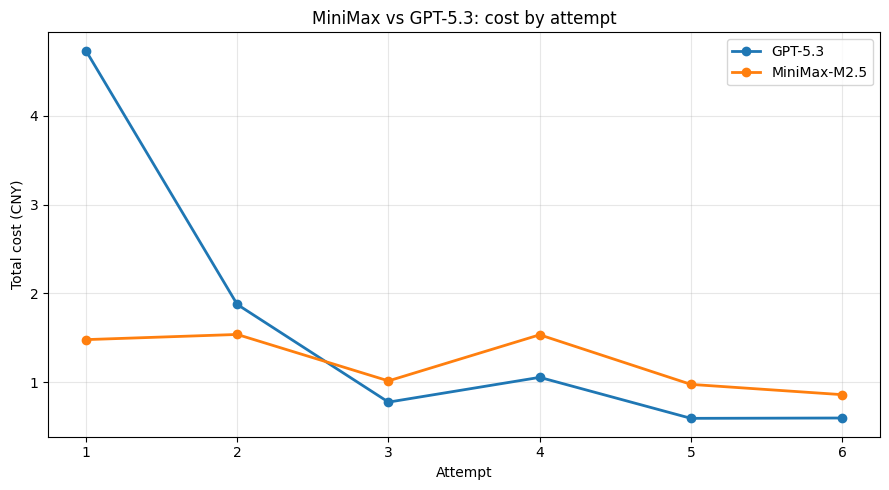

In [15]:
# 对比 MiniMax-M2.5 和 GPT-5.3 在不同 attempt 上的成本（人民币）
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TOKEN_PRICING_PATH = Path("/root/skill/analysis/rq1/token_pricing_cny_per_mtoken.json")
TOKEN_PRICING_CNY_PER_MTOKEN = json.loads(TOKEN_PRICING_PATH.read_text(encoding="utf-8"))
PRICE_CNY_PER_MTOKEN = {
    "MiniMax-M2.5": TOKEN_PRICING_CNY_PER_MTOKEN["MiniMax-M2.5"],
    "GPT-5.3": TOKEN_PRICING_CNY_PER_MTOKEN["GPT-5.3"],
}

MODEL_RESULTS = {
    "MiniMax-M2.5": Path(RESULTS_PATH_MINIMAX2_5),
    "GPT-5.3": Path(RESULTS_PATH_GPT5_3),
}
print(f"MiniMax price table: {PRICE_CNY_PER_MTOKEN['MiniMax-M2.5']}")
print(f"GPT price table: {PRICE_CNY_PER_MTOKEN['GPT-5.3']}")

def _load_attempt_cost_rows(model_name, path):
    data = json.loads(path.read_text(encoding="utf-8"))
    prices = PRICE_CNY_PER_MTOKEN[model_name]
    rows = []

    for task in data.get("tasks") or []:
        for attempt in task.get("attempts") or []:
            usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
            input_tokens = float(usage.get("input_tokens") or 0)
            output_tokens = float(usage.get("output_tokens") or 0)
            cache_read_tokens = float(usage.get("cache_read_tokens") or 0)
            cache_write_tokens = float(usage.get("cache_write_tokens") or 0)

            rows.append({
                "model": model_name,
                "task_id": task.get("task_id", ""),
                "attempt": int(attempt.get("attempt") or 0),
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "cache_read_tokens": cache_read_tokens,
                "cache_write_tokens": cache_write_tokens,
                "input_cost_cny": input_tokens / 1_000_000 * prices["input_tokens"],
                "output_cost_cny": output_tokens / 1_000_000 * prices["output_tokens"],
                "cache_read_cost_cny": cache_read_tokens / 1_000_000 * prices["cache_read_tokens"],
                "cache_write_cost_cny": cache_write_tokens / 1_000_000 * prices["cache_write_tokens"],
            })

    return rows

cost_rows = []
for model_name, result_path in MODEL_RESULTS.items():
    cost_rows.extend(_load_attempt_cost_rows(model_name, result_path))

df_cost = pd.DataFrame(cost_rows)
df_cost["total_cost_cny"] = df_cost[[
    "input_cost_cny",
    "output_cost_cny",
    "cache_read_cost_cny",
    "cache_write_cost_cny",
]].sum(axis=1)

attempt_cost_summary = (
    df_cost.groupby(["model", "attempt"], as_index=False)
    .agg(
        tasks=("task_id", "nunique"),
        input_tokens=("input_tokens", "sum"),
        output_tokens=("output_tokens", "sum"),
        cache_read_tokens=("cache_read_tokens", "sum"),
        cache_write_tokens=("cache_write_tokens", "sum"),
        input_cost_cny=("input_cost_cny", "sum"),
        output_cost_cny=("output_cost_cny", "sum"),
        cache_read_cost_cny=("cache_read_cost_cny", "sum"),
        cache_write_cost_cny=("cache_write_cost_cny", "sum"),
        total_cost_cny=("total_cost_cny", "sum"),
    )
    .sort_values(["model", "attempt"])
)
attempt_cost_summary["avg_cost_per_task_cny"] = (
    attempt_cost_summary["total_cost_cny"] / attempt_cost_summary["tasks"]
)

display(
    attempt_cost_summary[[
        "model",
        "attempt",
        "tasks",
        "input_tokens",
        "output_tokens",
        "cache_read_tokens",
        "cache_write_tokens",
        "input_cost_cny",
        "output_cost_cny",
        "cache_read_cost_cny",
        "cache_write_cost_cny",
        "total_cost_cny",
        "avg_cost_per_task_cny",
    ]].round(4)
)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, grp in attempt_cost_summary.groupby("model"):
    ax.plot(grp["attempt"], grp["total_cost_cny"], marker="o", linewidth=2, label=model_name)

ax.set_title("MiniMax vs GPT-5.3: cost by attempt")
ax.set_xlabel("Attempt")
ax.set_ylabel("Total cost (CNY)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 论文表 2 直接使用的 PinchBench 成本摘要（统一价格表，单位：CNY/task）
import json
from pathlib import Path
import pandas as pd

TOKEN_PRICING_PATH = Path("/root/skill/analysis/rq1/token_pricing_cny_per_mtoken.json")
TOKEN_PRICING_CNY_PER_MTOKEN = json.loads(TOKEN_PRICING_PATH.read_text(encoding="utf-8"))
PRICE_CNY_PER_MTOKEN = {
    "MiniMax-M2.5": TOKEN_PRICING_CNY_PER_MTOKEN["MiniMax-M2.5"],
    "GPT-5.3-Codex": TOKEN_PRICING_CNY_PER_MTOKEN["GPT-5.3-Codex"],
}
MODEL_RESULTS = {
    "MiniMax-M2.5": Path(RESULTS_PATH_MINIMAX2_5),
    "GPT-5.3-Codex": Path(RESULTS_PATH_GPT5_3),
}

def _cost_from_usage(usage, prices):
    usage = usage or {}
    return (
        float(usage.get("input_tokens") or 0) / 1_000_000 * prices["input_tokens"]
        + float(usage.get("output_tokens") or 0) / 1_000_000 * prices["output_tokens"]
        + float(usage.get("cache_read_tokens") or 0) / 1_000_000 * prices["cache_read_tokens"]
        + float(usage.get("cache_write_tokens") or 0) / 1_000_000 * prices["cache_write_tokens"]
    )

summary_rows = []
for model_name, result_path in MODEL_RESULTS.items():
    data = json.loads(result_path.read_text(encoding="utf-8"))
    tasks = data.get("tasks") or []
    prices = PRICE_CNY_PER_MTOKEN[model_name]
    first_success = 0
    final_success = 0
    first_attempt_total_cost = 0.0
    total_cost = 0.0

    for task in tasks:
        attempts = task.get("attempts") or []
        if attempts:
            first_attempt = attempts[0]
            first_grading = first_attempt.get("grading") or {}
            first_score = float(first_grading.get("score") or 0)
            first_max_score = float(first_grading.get("max_score") or 1)
            if first_max_score > 0 and first_score >= first_max_score:
                first_success += 1
            first_usage = ((first_attempt.get("execution") or {}).get("usage") or first_attempt.get("usage") or {})
            first_attempt_total_cost += _cost_from_usage(first_usage, prices)

        completion = task.get("completion") or {}
        final_score = float(completion.get("score") or 0)
        final_max_score = float(completion.get("max_score") or 1)
        if final_max_score > 0 and final_score >= final_max_score:
            final_success += 1

        for attempt in attempts:
            usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
            total_cost += _cost_from_usage(usage, prices)

    task_count = len(tasks)
    summary_rows.append({
        "model": model_name,
        "task_count": task_count,
        "first_success_rate": first_success / task_count if task_count else 0.0,
        "final_success_rate": final_success / task_count if task_count else 0.0,
        "attempt1_mean_cost_cny": first_attempt_total_cost / task_count if task_count else 0.0,
        "total_mean_cost_cny": total_cost / task_count if task_count else 0.0,
    })

pinchbench_main_results_df = pd.DataFrame(summary_rows)
display(pinchbench_main_results_df.round(4))


In [ ]:
# 动态停止策略：当本次 attempt 与前一次 attempt 的 score 相同，就在本次后停止统计
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TOKEN_PRICING_PATH = Path("/root/skill/analysis/rq1/token_pricing_cny_per_mtoken.json")
TOKEN_PRICING_CNY_PER_MTOKEN = json.loads(TOKEN_PRICING_PATH.read_text(encoding="utf-8"))
MODEL_RESULTS = {
    "MiniMax-M2.5": Path(RESULTS_PATH_MINIMAX2_5),
    "GPT-5.3-Codex": Path(RESULTS_PATH_GPT5_3),
}

def _attempt_cost_cny(attempt, prices):
    usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
    return (
        float(usage.get("input_tokens") or 0) / 1_000_000 * prices["input_tokens"]
        + float(usage.get("output_tokens") or 0) / 1_000_000 * prices["output_tokens"]
        + float(usage.get("cache_read_tokens") or 0) / 1_000_000 * prices["cache_read_tokens"]
        + float(usage.get("cache_write_tokens") or 0) / 1_000_000 * prices["cache_write_tokens"]
    )

def _cut_attempts_on_flat_score(task):
    kept = []
    prev_score = None
    for attempt in task.get("attempts") or []:
        score = (attempt.get("grading") or {}).get("score")
        kept.append(attempt)
        if prev_score is not None and score == prev_score:
            break
        prev_score = score
    return kept

def _first_success_attempt_from_attempts(attempts):
    for attempt in attempts:
        grading = attempt.get("grading") or {}
        score = grading.get("score")
        max_score = grading.get("max_score")
        if score is not None and max_score is not None and float(max_score) > 0 and float(score) >= float(max_score):
            return int(attempt.get("attempt") or 0)
    return None

dynamic_stop_rows = []
dynamic_attempt_rows = []

for model_name, result_path in MODEL_RESULTS.items():
    data = json.loads(result_path.read_text(encoding="utf-8"))
    prices = TOKEN_PRICING_CNY_PER_MTOKEN[model_name]
    tasks = data.get("tasks") or []
    first_success = 0
    final_success = 0
    first_attempt_total_cost = 0.0
    total_cost = 0.0
    truncated_task_count = 0

    for task in tasks:
        attempts = task.get("attempts") or []
        kept_attempts = _cut_attempts_on_flat_score(task)
        if len(kept_attempts) < len(attempts):
            truncated_task_count += 1

        dynamic_first_success_attempt = _first_success_attempt_from_attempts(kept_attempts)
        if dynamic_first_success_attempt == 1:
            first_success += 1
        if dynamic_first_success_attempt is not None:
            final_success += 1

        if attempts:
            first_attempt_total_cost += _attempt_cost_cny(attempts[0], prices)
        total_cost += sum(_attempt_cost_cny(attempt, prices) for attempt in kept_attempts)

        dynamic_stop_rows.append({
            "model": model_name,
            "task_id": task.get("task_id", ""),
            "original_attempt_count": len(attempts),
            "dynamic_attempt_count": len(kept_attempts),
            "dynamic_first_success_attempt": dynamic_first_success_attempt,
            "truncated": len(kept_attempts) < len(attempts),
            "dynamic_total_cost_cny": sum(_attempt_cost_cny(attempt, prices) for attempt in kept_attempts),
        })

    task_count = len(tasks)
    success_at_k = {}
    for k in range(1, 7):
        dynamic_successes = 0
        for task in tasks:
            kept_attempts = _cut_attempts_on_flat_score(task)
            dynamic_first_success_attempt = _first_success_attempt_from_attempts(kept_attempts)
            if dynamic_first_success_attempt is not None and dynamic_first_success_attempt <= k:
                dynamic_successes += 1
        success_at_k[k] = dynamic_successes / task_count if task_count else 0.0
        dynamic_attempt_rows.append({
            "model": model_name,
            "attempt": k,
            "cumulative_success_rate": success_at_k[k],
        })

    dynamic_stop_rows.append({
        "model": model_name,
        "task_id": "__summary__",
        "original_attempt_count": task_count,
        "dynamic_attempt_count": task_count,
        "dynamic_first_success_attempt": None,
        "truncated": truncated_task_count,
        "dynamic_total_cost_cny": total_cost / task_count if task_count else 0.0,
        "attempt1_mean_cost_cny": first_attempt_total_cost / task_count if task_count else 0.0,
        "first_success_rate": first_success / task_count if task_count else 0.0,
        "final_success_rate": final_success / task_count if task_count else 0.0,
        "truncated_task_count": truncated_task_count,
    })

dynamic_stop_df = pd.DataFrame(dynamic_stop_rows)
dynamic_stop_summary_df = dynamic_stop_df[dynamic_stop_df["task_id"] == "__summary__"].copy()
dynamic_stop_summary_df = dynamic_stop_summary_df[[
    "model", "first_success_rate", "final_success_rate",
    "attempt1_mean_cost_cny", "dynamic_total_cost_cny", "truncated_task_count"
]].rename(columns={"dynamic_total_cost_cny": "total_mean_cost_cny"})
display(dynamic_stop_summary_df.round(4))

dynamic_attempt_df = pd.DataFrame(dynamic_attempt_rows)
dynamic_attempt_df["marginal_gain"] = dynamic_attempt_df.groupby("model")["cumulative_success_rate"].diff().fillna(dynamic_attempt_df["cumulative_success_rate"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model_name, df_model in dynamic_attempt_df.groupby("model"):
    axes[0].plot(df_model["attempt"], df_model["cumulative_success_rate"], marker="o", linewidth=2.5, label=model_name)
    axes[1].bar(
        [x + (-0.18 if model_name == "MiniMax-M2.5" else 0.18) for x in df_model["attempt"]],
        df_model["marginal_gain"],
        width=0.36,
        alpha=0.85,
        label=model_name,
    )

axes[0].set_title("Dynamic stop: cumulative success by attempt")
axes[0].set_xlabel("Attempt")
axes[0].set_ylabel("Cumulative success rate")
axes[0].set_xticks(range(1, 7))
axes[0].set_ylim(0.25, 0.8)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Dynamic stop: marginal success gain")
axes[1].set_xlabel("Attempt")
axes[1].set_ylabel("Marginal success gain")
axes[1].set_xticks(range(1, 7))
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Task-level truncation details:")
display(dynamic_stop_df[dynamic_stop_df["task_id"] != "__summary__"].sort_values(["model", "truncated", "dynamic_total_cost_cny", "task_id"], ascending=[True, False, False, True]).reset_index(drop=True))


In [25]:
# 依赖（如无则 pip install matplotlib pandas）
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False


with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

model = data.get("model", "unknown")
run_id = data.get("run_id", "")
tasks = data.get("tasks", [])
efficiency = data.get("efficiency", {})

print(f"Model: {model}  Run: {run_id}   Tasks: {len(tasks)}")

Model: minimax-cn/MiniMax-M2.5  Run: 0064+0066+0072+0073   Tasks: 23


In [26]:
# 解析：按 task 汇总 + 按 attempts 拆开每一轮
def parse_task(t):
    name = (t.get("frontmatter") or {}).get("name") or t.get("task_id", "")
    comp = t.get("completion") or {}
    score = float(comp.get("score", 0))
    max_score = float(comp.get("max_score", 1) or 1)
    attempt_count = int(t.get("attempt_count", 1))
    execution_time = float(t.get("execution_time", 0))
    attempts_detail = []
    for a in t.get("attempts") or []:
        g = a.get("grading") or {}
        ex = a.get("execution") or {}
        attempts_detail.append({
            "attempt": int(a.get("attempt", 0)),
            "score": float(g.get("score", 0)),
            "max_score": float(g.get("max_score", 1) or 1),
            "execution_time": float(ex.get("execution_time", 0)),
            "status": ex.get("status", ""),
        })
    return {
        "task_id": t.get("task_id", ""),
        "name": name,
        "score": score,
        "max_score": max_score,
        "execution_time": execution_time,
        "attempt_count": attempt_count,
        "attempts": attempts_detail,
    }

rows = [parse_task(t) for t in tasks]
task_ids = [r["task_id"] for r in rows]
scores = [r["score"] for r in rows]
max_scores = [r["max_score"] for r in rows]
times = [r["execution_time"] for r in rows]
attempt_counts = [r["attempt_count"] for r in rows]
print("Parsed", len(rows), "tasks. Sample:", rows[0]["task_id"], "score", rows[0]["score"], "attempts", rows[0]["attempt_count"])

Parsed 23 tasks. Sample: task_00_sanity score 1.0 attempts 1


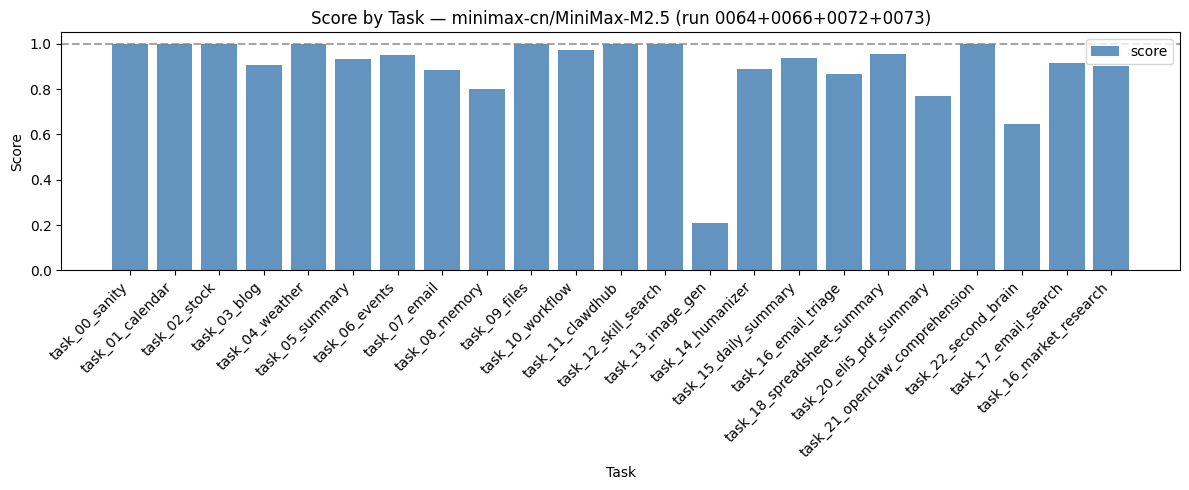

0.8924565217391303


In [27]:
# 图1：各任务得分（按 task）
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(task_ids))
bars = ax.bar(x, scores, color="steelblue", alpha=0.85, label="score")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_xlabel("Task")
ax.set_title(f"Score by Task — {model} (run {run_id})")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()
print(sum(scores)/len(scores))

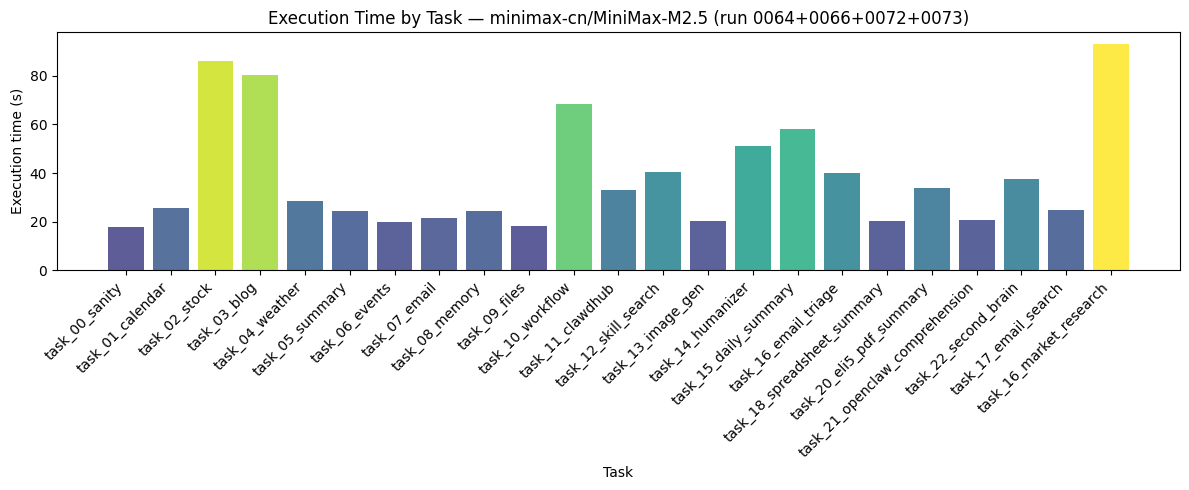

In [28]:
# 图2：各任务耗时（秒）
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis([t / max(times) if max(times) > 0 else 0 for t in times])
ax.bar(x, times, color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Execution time (s)")
ax.set_xlabel("Task")
ax.set_title(f"Execution Time by Task — {model} (run {run_id})")
plt.tight_layout()
plt.show()

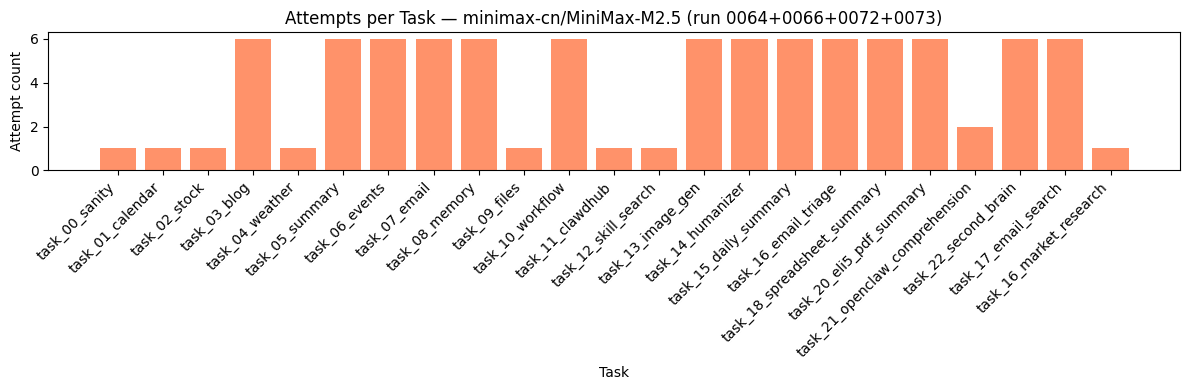

In [29]:
# 图3：各任务 attempt 次数
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, attempt_counts, color="coral", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Attempt count")
ax.set_xlabel("Task")
ax.set_title(f"Attempts per Task — {model} (run {run_id})")
plt.tight_layout()
plt.show()

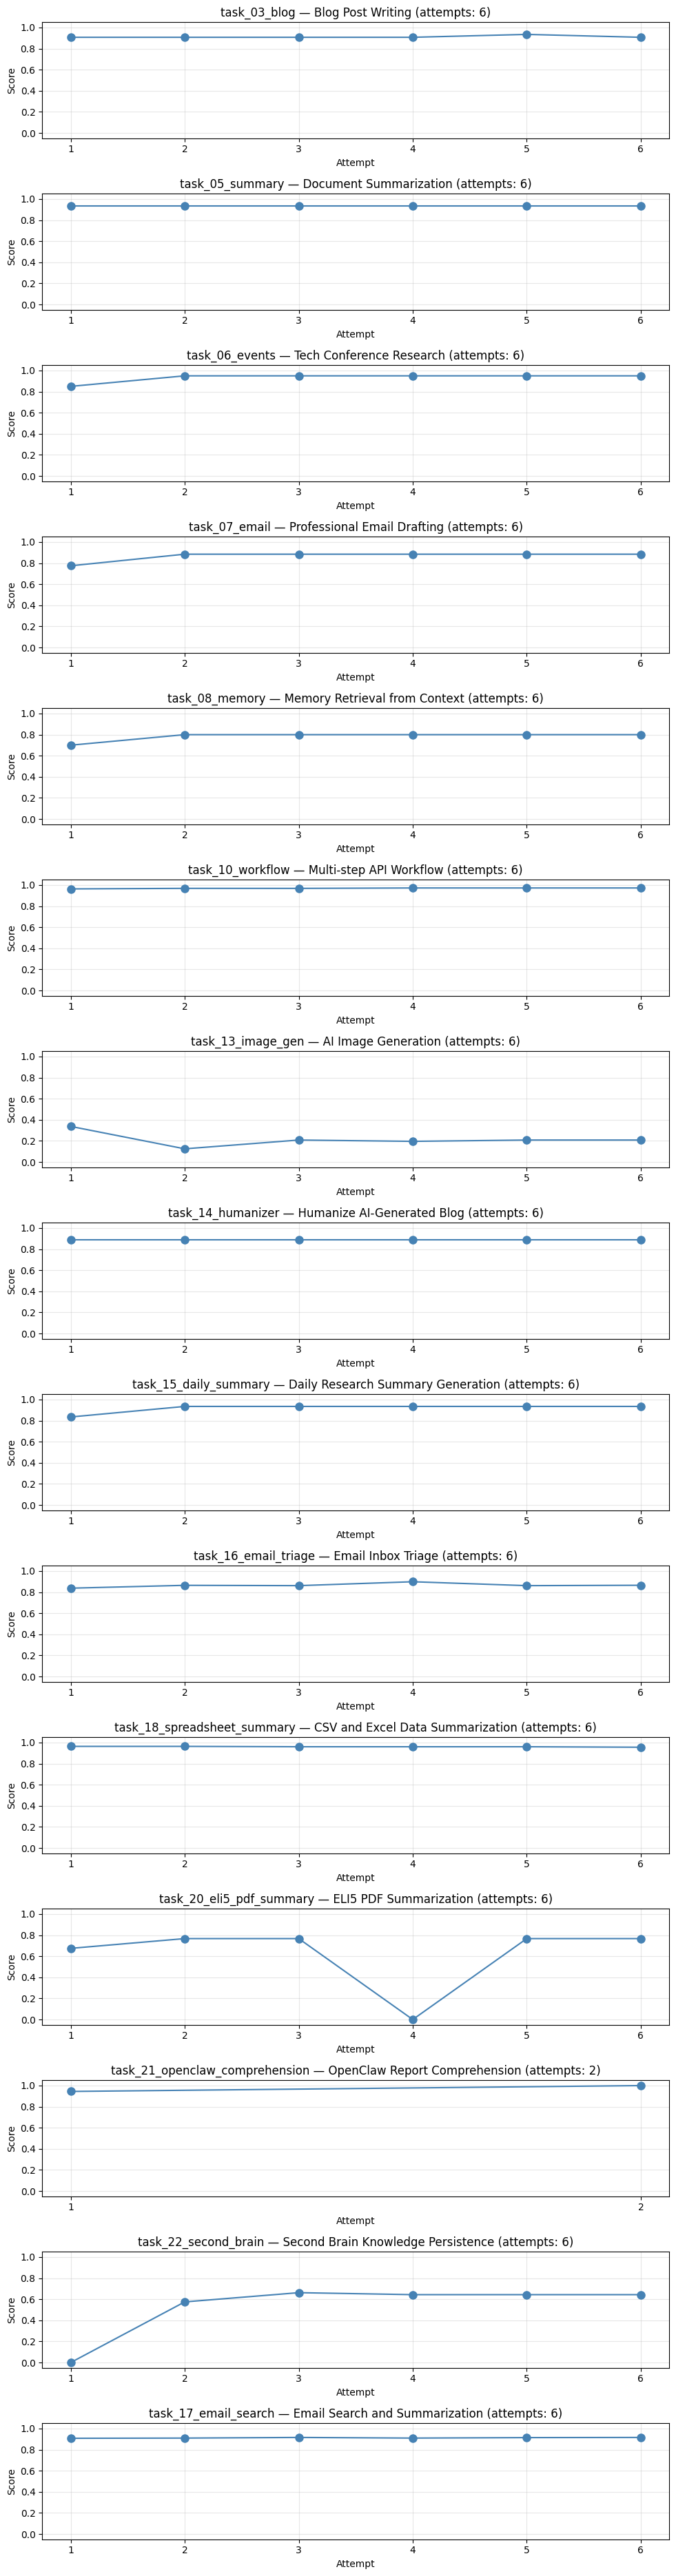

In [30]:
# 汇总每个 task 的每一轮 attempt：得分、耗时、状态
attempt_rows = []
for r in rows:
    for a in r["attempts"]:
        attempt_rows.append({
            "task_id": r["task_id"],
            "name": r["name"],
            "attempt": a["attempt"],
            "score": a["score"],
            "max_score": a["max_score"],
            "execution_time": a["execution_time"],
            "status": a["status"],
        })

# 仅多 attempt 的 task：画 尝试序号 vs 得分
multi = [r for r in rows if r["attempt_count"] > 1]
if not multi:
    print("没有多轮 attempt 的 task。")
else:
    fig, axes = plt.subplots(len(multi), 1, figsize=(10, 2.5 * len(multi)), sharex=False)
    if len(multi) == 1:
        axes = [axes]
    for i, r in enumerate(multi):
        ax = axes[i]
        atts = r["attempts"]
        nums = [x["attempt"] for x in atts]
        scs = [x["score"] for x in atts]
        ax.plot(nums, scs, "o-", color="steelblue", markersize=8)
        ax.set_ylabel("Score")
        ax.set_xlabel("Attempt")
        ax.set_title(f"{r['task_id']} — {r['name']} (attempts: {r['attempt_count']})")
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(nums)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [31]:
# 表：每个 task 的每一轮 attempt（得分 + 耗时）
if attempt_rows:
    try:
        import pandas as pd
        df = pd.DataFrame(attempt_rows)
        df["score_pct"] = (df["score"] / df["max_score"].replace(0, 1) * 100).round(1)
        display(df[["task_id", "attempt", "score", "max_score", "score_pct", "execution_time", "status"]])
    except Exception:
        for row in attempt_rows[:20]:
            print(row)
        if len(attempt_rows) > 20:
            print("...", len(attempt_rows) - 20, "more rows")

,task_id,attempt,score,max_score,score_pct,execution_time,status
0,task_00_sanity,1,1.0000,1.0,100.0,17.853824,success
1,task_01_calendar,1,1.0000,1.0,100.0,25.826634,success
2,task_02_stock,1,1.0000,1.0,100.0,86.028892,success
3,task_03_blog,1,0.9075,1.0,90.8,36.904215,success
4,task_03_blog,2,0.9075,1.0,90.8,2.308990,success
...,...,...,...,...,...,...,...
89,task_17_email_search,3,0.9160,1.0,91.6,-39.418853,success
90,task_17_email_search,4,0.9100,1.0,91.0,22.201181,success
91,task_17_email_search,5,0.9145,1.0,91.4,-66.600903,success
92,task_17_email_search,6,0.9160,1.0,91.6,1.495772,success


In [32]:
# 本 run 效率汇总（来自 JSON 顶层 efficiency）
for k, v in (efficiency or {}).items():
    if k != "per_task":
        print(f"  {k}: {v}")

  total_tokens: 8859695.0
  total_input_tokens: 3360921.0
  total_output_tokens: 104007.0
  total_cache_tokens: 0.0
  total_cache_read_tokens: 0.0
  total_cache_write_tokens: 0.0
  total_cost_usd: 0.0
  total_requests: 408.0
  total_execution_time_seconds: 888.69
  tasks_with_usage_data: 23
  tokens_per_task: 385204.1304347826
  cost_per_task_usd: 0.0
  success_rate: 0.34782608695652173
  success_per_1k_tokens: 0.0009029656212770304
  score_per_1k_tokens: 0.0023168010590658033
  score_per_dollar: None
  success_per_dollar: None
  success_at_k: {}


In [33]:
# 每个模型的总体成本、成功成本、失败成本，以及成功任务平均成本（人民币）
import json
from pathlib import Path
import pandas as pd

TOKEN_PRICING_PATH = Path("/root/skill/analysis/rq1/token_pricing_cny_per_mtoken.json")
TOKEN_PRICING_CNY_PER_MTOKEN = json.loads(TOKEN_PRICING_PATH.read_text(encoding="utf-8"))
PRICE_CNY_PER_MTOKEN = {
    "MiniMax-M2.5": TOKEN_PRICING_CNY_PER_MTOKEN["MiniMax-M2.5"],
    "GPT-5.3": TOKEN_PRICING_CNY_PER_MTOKEN["GPT-5.3"],
}

MODEL_RESULTS = {
    "MiniMax-M2.5": Path(RESULTS_PATH_MINIMAX2_5),
    "GPT-5.3": Path(RESULTS_PATH_GPT5_3),
}
print(f"MiniMax price table: {PRICE_CNY_PER_MTOKEN['MiniMax-M2.5']}")
print(f"GPT price table: {PRICE_CNY_PER_MTOKEN['GPT-5.3']}")

def _compute_task_cost_cny(task, prices):
    total = 0.0
    for attempt in task.get("attempts") or []:
        usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
        total += float(usage.get("input_tokens") or 0) / 1_000_000 * prices["input_tokens"]
        total += float(usage.get("output_tokens") or 0) / 1_000_000 * prices["output_tokens"]
        total += float(usage.get("cache_read_tokens") or 0) / 1_000_000 * prices["cache_read_tokens"]
        total += float(usage.get("cache_write_tokens") or 0) / 1_000_000 * prices["cache_write_tokens"]
    return total

cost_summary_rows = []
for model_name, result_path in MODEL_RESULTS.items():
    data = json.loads(result_path.read_text(encoding="utf-8"))
    prices = PRICE_CNY_PER_MTOKEN[model_name]

    overall_total_cost_cny = 0.0
    success_cost_cny = 0.0
    failed_cost_cny = 0.0
    success_task_count = 0

    for task in data.get("tasks") or []:
        task_cost_cny = _compute_task_cost_cny(task, prices)
        overall_total_cost_cny += task_cost_cny

        grading = task.get("grading") or {}
        score = float(grading.get("score") or 0)
        max_score = float(grading.get("max_score") or 1)
        task_success = max_score > 0 and score >= max_score

        if task_success:
            success_cost_cny += task_cost_cny
            success_task_count += 1
        else:
            failed_cost_cny += task_cost_cny

    cost_summary_rows.append({
        "model": model_name,
        "overall_total_cost_cny": overall_total_cost_cny,
        "success_cost_cny": success_cost_cny,
        "failed_cost_cny": failed_cost_cny,
        "success_task_count": success_task_count,
        "cost_per_success_task_cny": success_cost_cny / success_task_count if success_task_count else 0.0,
    })

cost_summary_df = pd.DataFrame(cost_summary_rows)
try:
    display(cost_summary_df.round(4))
except NameError:
    print(cost_summary_df.round(4).to_string(index=False))


MiniMax price table: {'input_tokens': 1.44, 'cache_read_tokens': 0.288, 'cache_write_tokens': 1.44, 'output_tokens': 5.76}
GPT price table: {'input_tokens': 6.125, 'cache_read_tokens': 0.615, 'cache_write_tokens': 6.125, 'output_tokens': 49.0}


,model,overall_total_cost_cny,success_cost_cny,failed_cost_cny,success_task_count,cost_per_success_task_cny
0,MiniMax-M2.5,7.3979,1.0815,6.3164,8,0.1352
1,GPT-5.3,9.6278,4.2551,5.3726,17,0.2503
